In [ ]:
"""
National Bridge Inspection Data - Preprocessing Pipeline
Notebook 1: Data Loading & Preprocessing (Steps 1-4)

Team: Team 03
Authors: Vashishth Doshi, Priyal Shah
Course: 95-885 Data Science and Big Data, Fall 2025

Target: BRIDGE_CONDITION (G=Good, F=Fair, P=Poor)
Strategy: Train on 2023+2024, Test on 2025

Steps in this notebook:
1. Data Leakage Prevention (temporal train/test split)
2. Sparse Column Identification (variance threshold)
3. Duplicate Row Removal
4. Outlier Detection and Handling
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("NATIONAL BRIDGE INSPECTION - DATA PREPROCESSING PIPELINE")
print(f"Random state set to: {RANDOM_STATE}")

NATIONAL BRIDGE INSPECTION - DATA PREPROCESSING PIPELINE
Random state set to: 42


In [ ]:
"""
Load bridge inspection data for 2023, 2024, and 2025
Check for column consistency across years
"""
# Load each year's data
df_2023 = pd.read_csv('2023HwyBridgesDelimitedAllStates.csv')
df_2024 = pd.read_csv('2024HwyBridgesDelimitedAllStates.csv', on_bad_lines = "skip", engine= "python")
df_2025 = pd.read_csv('2025HwyBridgesDelimitedAllStates.csv')

# Add year column to track data source
df_2023['DATA_YEAR'] = 2023
df_2024['DATA_YEAR'] = 2024
df_2025['DATA_YEAR'] = 2025

print(f"\nData Loaded:")
print(f"   2023: {df_2023.shape[0]:,} rows × {df_2023.shape[1]} columns")
print(f"   2024: {df_2024.shape[0]:,} rows × {df_2024.shape[1]} columns")
print(f"   2025: {df_2025.shape[0]:,} rows × {df_2025.shape[1]} columns")
print(f"\n   Total: {df_2023.shape[0] + df_2024.shape[0] + df_2025.shape[0]:,} rows")


Data Loaded:
   2023: 621,581 rows × 124 columns
   2024: 623,217 rows × 124 columns
   2025: 624,193 rows × 124 columns

   Total: 1,868,991 rows


In [ ]:
"""
Verify that all three years have the same columns
This is critical for combining datasets
"""
print("CHECKING COLUMN CONSISTENCY ACROSS YEARS")
# Get column sets for each year
cols_2023 = set(df_2023.columns)
cols_2024 = set(df_2024.columns)
cols_2025 = set(df_2025.columns)

# Find common columns
common_cols = cols_2023 & cols_2024 & cols_2025
print(f"\nCommon columns across all years: {len(common_cols)}")

# Find columns unique to each year
only_2023 = cols_2023 - cols_2024 - cols_2025
only_2024 = cols_2024 - cols_2023 - cols_2025
only_2025 = cols_2025 - cols_2023 - cols_2024

if len(only_2023) > 0:
    print(f"\n Columns only in 2023: {only_2023}")
if len(only_2024) > 0:
    print(f" Columns only in 2024: {only_2024}")
if len(only_2025) > 0:
    print(f" Columns only in 2025: {only_2025}")

# Check if BRIDGE_CONDITION exists in all years
if 'BRIDGE_CONDITION' in common_cols:
    print(f"\nTarget variable 'BRIDGE_CONDITION' exists in all years")
else:
    print(f"\nERROR: BRIDGE_CONDITION missing in some years")
    print(f"   2023: {'BRIDGE_CONDITION' in cols_2023}")
    print(f"   2024: {'BRIDGE_CONDITION' in cols_2024}")
    print(f"   2025: {'BRIDGE_CONDITION' in cols_2025}")

# Keep only common columns for consistency
print(f"\nKeeping only common columns: {len(common_cols)}")
df_2023 = df_2023[list(common_cols)]
df_2024 = df_2024[list(common_cols)]
df_2025 = df_2025[list(common_cols)]

print(f"\n   After filtering:")
print(f"   2023: {df_2023.shape}")
print(f"   2024: {df_2024.shape}")
print(f"   2025: {df_2025.shape}")

CHECKING COLUMN CONSISTENCY ACROSS YEARS

Common columns across all years: 124

Target variable 'BRIDGE_CONDITION' exists in all years

Keeping only common columns: 124

   After filtering:
   2023: (621581, 124)
   2024: (623217, 124)
   2025: (624193, 124)


TARGET VARIABLE ANALYSIS ACROSS YEARS

2023 Distribution:
   G (Good): 275,117 (44.26%)
   F (Fair): 304,060 (48.92%)
   P (Poor): 42,404 ( 6.82%)

2024 Distribution:
   G (Good): 274,859 (44.10%)
   F (Fair): 306,278 (49.14%)
   P (Poor): 42,080 ( 6.75%)

2025 Distribution:
   G (Good): 272,779 (43.70%)
   F (Fair): 309,729 (49.62%)
   P (Poor): 41,685 ( 6.68%)


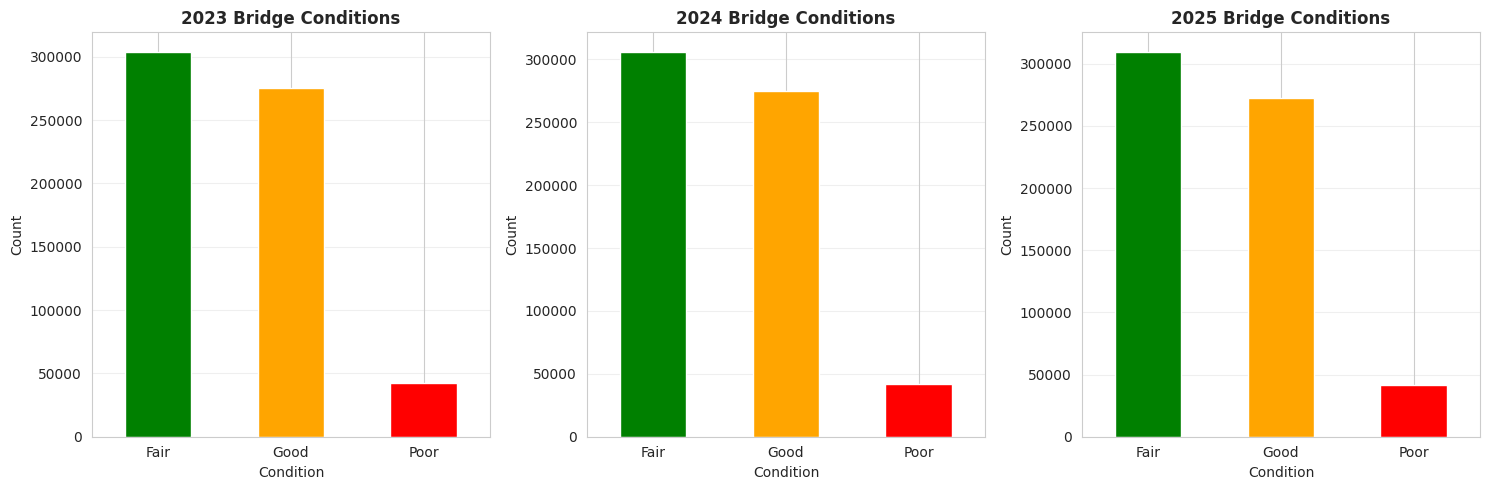


CLASS IMBALANCE NOTE:
   'Poor' (P) bridges are consistently ~6-7% across all years
   This will require special handling in modeling (SMOTE, class weights)


In [ ]:
"""
Analyze BRIDGE_CONDITION distribution for each year
Check if class distributions are similar
"""
print("TARGET VARIABLE ANALYSIS ACROSS YEARS")
# Function to display distribution
def show_distribution(df, year):
    print(f"\n{year} Distribution:")
    counts = df['BRIDGE_CONDITION'].value_counts().sort_index()
    props = df['BRIDGE_CONDITION'].value_counts(normalize=True).sort_index()

    for condition in ['G', 'F', 'P']:
        if condition in counts.index:
            print(f"   {condition} ({'Good' if condition=='G' else 'Fair' if condition=='F' else 'Poor'}): "
                  f"{counts[condition]:6,} ({props[condition]:6.2%})")
    return counts

counts_2023 = show_distribution(df_2023, "2023")
counts_2024 = show_distribution(df_2024, "2024")
counts_2025 = show_distribution(df_2025, "2025")

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (df_year, year, counts) in enumerate([
    (df_2023, '2023', counts_2023),
    (df_2024, '2024', counts_2024),
    (df_2025, '2025', counts_2025)
]):
    counts.plot(kind='bar', ax=axes[idx], color=['green', 'orange', 'red'])
    axes[idx].set_title(f'{year} Bridge Conditions', fontweight='bold')
    axes[idx].set_xlabel('Condition')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticklabels(['Fair', 'Good', 'Poor'], rotation=0)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCLASS IMBALANCE NOTE:")
print("   'Poor' (P) bridges are consistently ~6-7% across all years")
print("   This will require special handling in modeling (SMOTE, class weights)")

In [ ]:
"""
STEP 1: DATA LEAKAGE PREVENTION
Critical: We split before preprocessing data.

Strategy: Temporal split
- Training: 2023 + 2024 data
- Testing: 2025 data (unseen future data)

This simulates real-world scenario: predict 2025 conditions using historical data
"""
print("STEP 1: TEMPORAL TRAIN/TEST SPLIT")
# Combine 2023 and 2024 for training
df_train = pd.concat([df_2023, df_2024], ignore_index=True)
df_test = df_2025.copy()

print(f"\nData Split:")
print(f"   Training (2023+2024): {df_train.shape[0]:,} rows × {df_train.shape[1]} columns")
print(f"   Testing (2025):       {df_test.shape[0]:,} rows × {df_test.shape[1]} columns")
print(f"   Split ratio:          {df_train.shape[0]/(df_train.shape[0]+df_test.shape[0]):.1%} train / "
      f"{df_test.shape[0]/(df_train.shape[0]+df_test.shape[0]):.1%} test")

# Separate features (X) and target (y)
X_train = df_train.drop('BRIDGE_CONDITION', axis=1)
y_train = df_train['BRIDGE_CONDITION']

X_test = df_test.drop('BRIDGE_CONDITION', axis=1)
y_test = df_test['BRIDGE_CONDITION']

print(f"\n   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_test:  {y_test.shape}")

# Verify stratification
print(f"\nClass Distribution Verification:")
print(f"\n   Training set:")
for condition, prop in y_train.value_counts(normalize=True).sort_index().items():
    print(f"      {condition}: {prop:.2%}")

print(f"\n   Test set:")
for condition, prop in y_test.value_counts(normalize=True).sort_index().items():
    print(f"      {condition}: {prop:.2%}")

print(f"\nNote: All preprocessing steps from here will be on training data only")

STEP 1: TEMPORAL TRAIN/TEST SPLIT

Data Split:
   Training (2023+2024): 1,244,798 rows × 124 columns
   Testing (2025):       624,193 rows × 124 columns
   Split ratio:          66.6% train / 33.4% test

   X_train: (1244798, 123)
   y_train: (1244798,)
   X_test:  (624193, 123)
   y_test:  (624193,)

Class Distribution Verification:

   Training set:
      F: 49.03%
      G: 44.18%
      P: 6.79%

   Test set:
      F: 49.62%
      G: 43.70%
      P: 6.68%

Note: All preprocessing steps from here will be on training data only


In [ ]:
"""
STEP 3: DUPLICATE ROW REMOVAL
==============================
Check for and remove duplicate rows in TRAINING data only
"""
print("STEP 3: DUPLICATE ROW IDENTIFICATION AND REMOVAL")
# Check duplicates in training data
n_duplicates_train = X_train.duplicated().sum()
print(f"\nTraining Data Duplicate Analysis:")
print(f"   Total rows: {len(X_train):,}")
print(f"   Duplicate rows: {n_duplicates_train:,}")
print(f"   Percentage: {n_duplicates_train/len(X_train)*100:.3f}%")

if n_duplicates_train > 0:
    # Remove duplicates from training data
    # Need to keep indices aligned between X_train and y_train
    duplicate_mask = ~X_train.duplicated()
    X_train = X_train[duplicate_mask]
    y_train = y_train[duplicate_mask]

    print(f"\n    Duplicates removed from training data")
    print(f"   New training size: {len(X_train):,} rows")
else:
    print(f"\n    No duplicate rows found in training data")

# Check duplicates in test data (for information only)
n_duplicates_test = X_test.duplicated().sum()
print(f"\n Test Data Duplicate Analysis (informational):")
print(f"   Total rows: {len(X_test):,}")
print(f"   Duplicate rows: {n_duplicates_test:,}")
print(f"   Percentage: {n_duplicates_test/len(X_test)*100:.3f}%")

# Final shapes
print(f"\n Final Shapes After Duplicate Removal:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_test:  {y_test.shape}")

STEP 3: DUPLICATE ROW IDENTIFICATION AND REMOVAL

Training Data Duplicate Analysis:
   Total rows: 1,244,798
   Duplicate rows: 0
   Percentage: 0.000%

    No duplicate rows found in training data

 Test Data Duplicate Analysis (informational):
   Total rows: 624,193
   Duplicate rows: 0
   Percentage: 0.000%

 Final Shapes After Duplicate Removal:
   X_train: (1244798, 123)
   y_train: (1244798,)
   X_test:  (624193, 123)
   y_test:  (624193,)


In [ ]:
"""
STEP 2: SPARSE COLUMN IDENTIFICATION
=====================================
Identify numeric vs non-numeric columns
Calculate variance to find uninformative features
.FIT variance threshold on TRAINING data only
"""
print("STEP 2: SPARSE COLUMN IDENTIFICATION")

# Identify column types (exclude DATA_YEAR since we added it)
if 'DATA_YEAR' in X_train.columns:
    X_train = X_train.drop('DATA_YEAR', axis=1)
    X_test = X_test.drop('DATA_YEAR', axis=1)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nColumn Type Analysis:")
print(f"   Total columns: {len(X_train.columns)}")
print(f"   Numeric columns: {len(numeric_cols)}")
print(f"   Non-numeric columns: {len(non_numeric_cols)}")

if len(non_numeric_cols) > 0:
    print(f"\n   Non-numeric columns (first 10):")
    for col in non_numeric_cols[:10]:
        print(f"      - {col}: {X_train[col].dtype}")

STEP 2: SPARSE COLUMN IDENTIFICATION

Column Type Analysis:
   Total columns: 122
   Numeric columns: 81
   Non-numeric columns: 41

   Non-numeric columns (first 10):
      - RAILINGS_036A: object
      - FEATURES_DESC_006A: object
      - UNDCLRENCE_EVAL_069: object
      - STRUCTURE_NUMBER_008: object
      - ROUTE_NUMBER_005D: object
      - SCOUR_CRITICAL_113: object
      - APPR_RAIL_036C: object
      - DECK_STRUCTURE_TYPE_107: object
      - OPEN_CLOSED_POSTED_041: object
      - CULVERT_COND_062: object



Variance Analysis (Training Data):

   10 LOWEST variance columns:
RECORD_TYPE_005A        0.0000
TOLL_020                0.0177
STRUCTURE_FLARED_035    0.0249
WORK_DONE_BY_075B       0.0722
FEDERAL_LANDS_105       0.1135
NATIONAL_NETWORK_110    0.1414
STRAHNET_HIGHWAY_100    0.1488
HIGHWAY_SYSTEM_104      0.1806
BASE_HWY_NETWORK_012    0.1945
TRAFFIC_DIRECTION_102   0.1991
dtype: float64

   10 HIGHEST variance columns:
DECK_AREA                        6528885.2854
ROADWAY_IMP_COST_095           328423701.0118
ADT_029                        448317958.9676
PLACE_CODE_004                 830328898.1510
FUTURE_ADT_114                 849821482.5763
BRIDGE_IMP_COST_094           3293816141.9640
TOTAL_IMP_COST_096            3480657523.6575
LAT_016                   25781179169581.1797
LONG_017                 201304600952497.5000
CRITICAL_FACILITY_006B                    NaN
dtype: float64


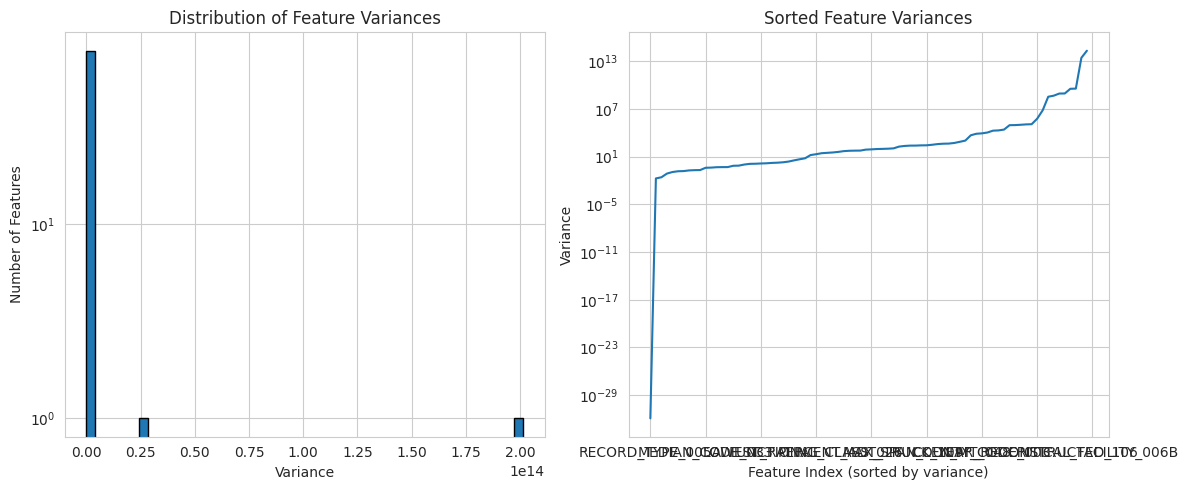

In [ ]:
"""
Calculate variance for each numeric feature
Identify low-variance (uninformative) columns
"""

# Calculate variance for numeric columns only
variances = X_train[numeric_cols].var().sort_values()

print(f"\nVariance Analysis (Training Data):")
print(f"\n   10 LOWEST variance columns:")
print(variances.head(10))

print(f"\n   10 HIGHEST variance columns:")
print(variances.tail(10))

# Visualize variance distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
variances.plot(kind='hist', bins=50, edgecolor='black')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Variances')
plt.yscale('log')

plt.subplot(1, 2, 2)
variances.plot(kind='line')
plt.xlabel('Feature Index (sorted by variance)')
plt.ylabel('Variance')
plt.title('Sorted Feature Variances')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
"""
Remove low-variance features using VarianceThreshold
FIT on training data, TRANSFORM both train and test
Handle columns with NaN variance (all missing values)
"""

# Set variance threshold
VARIANCE_THRESHOLD = 0.01

# Remove columns with NaN variance (all missing)
numeric_cols_valid = [col for col in numeric_cols if X_train[col].var() == X_train[col].var()]  # NaN != NaN
print(f"\nRemoving columns with NaN variance (all missing):")
nan_var_cols = [col for col in numeric_cols if X_train[col].var() != X_train[col].var()]
for col in nan_var_cols:
    print(f"   - {col}")

# Create and fit variance selector on valid numeric columns only
variance_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_train_numeric = X_train[numeric_cols_valid].values
variance_selector.fit(X_train_numeric)

# Get support mask
support_mask = variance_selector.get_support()
kept_cols = [col for col, keep in zip(numeric_cols_valid, support_mask) if keep]
removed_cols = [col for col, keep in zip(numeric_cols_valid, support_mask) if not keep]

print(f"\nVariance Filtering Results:")
print(f"   Threshold: {VARIANCE_THRESHOLD}")
print(f"   Original numeric features: {len(numeric_cols)}")
print(f"   Valid numeric features: {len(numeric_cols_valid)}")
print(f"   Features kept: {len(kept_cols)}")
print(f"   Features removed: {len(removed_cols) + len(nan_var_cols)}")

if len(removed_cols) > 0:
    print(f"\n   Removed columns (variance < {VARIANCE_THRESHOLD}):")
    for col in removed_cols:
        var_value = X_train[col].var()
        print(f"      - {col}: variance = {var_value:.6f}")

# Apply to both train and test
X_train_filtered = X_train[kept_cols + non_numeric_cols]
X_test_filtered = X_test[kept_cols + non_numeric_cols]

print(f"\n   Shapes after variance filtering:")
print(f"      X_train: {X_train.shape} -> {X_train_filtered.shape}")
print(f"      X_test:  {X_test.shape} -> {X_test_filtered.shape}")

# Update X_train and X_test
X_train = X_train_filtered
X_test = X_test_filtered


Removing columns with NaN variance (all missing):
   - CRITICAL_FACILITY_006B

Variance Filtering Results:
   Threshold: 0.01
   Original numeric features: 81
   Valid numeric features: 80
   Features kept: 79
   Features removed: 2

   Removed columns (variance < 0.01):
      - RECORD_TYPE_005A: variance = 0.000000

   Shapes after variance filtering:
      X_train: (1244798, 122) -> (1244798, 120)
      X_test:  (624193, 122) -> (624193, 120)


In [ ]:
"""
STEP 4: OUTLIER DETECTION
Method 1: Interquartile Range (IQR)

Detect outliers on TRAINING data only
We identify but don't remove yet - just flag them
"""
print("STEP 4: OUTLIER DETECTION")

def detect_outliers_iqr(df, columns, multiplier=1.5):
    """
    Detect outliers using IQR method

    Parameters:
    -----------
    df : DataFrame
    columns : list of column names (numeric only)
    multiplier : float, IQR multiplier (default 1.5)

    Returns:
    --------
    outlier_mask : boolean array (True = outlier)
    outlier_counts : dict of outlier counts per column
    """
    outlier_mask = np.zeros(len(df), dtype=bool)
    outlier_counts = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_mask |= col_outliers
        outlier_counts[col] = col_outliers.sum()

    return outlier_mask, outlier_counts

# Detect outliers on training data
print("\nMethod 1: IQR (Interquartile Range)")
print("   Multiplier: 1.5 (standard)")

# Only check numeric columns
numeric_cols_current = X_train.select_dtypes(include=[np.number]).columns.tolist()
train_outlier_mask, train_outlier_counts = detect_outliers_iqr(
    X_train,
    numeric_cols_current,
    multiplier=1.5
)

n_outliers_train = train_outlier_mask.sum()
print(f"\n   Training Data:")
print(f"      Total rows: {len(X_train):,}")
print(f"      Rows with outliers: {n_outliers_train:,}")
print(f"      Percentage: {n_outliers_train/len(X_train)*100:.2f}%")

# Show top columns with outliers
sorted_outliers = sorted(train_outlier_counts.items(), key=lambda x: x[1], reverse=True)
print(f"\n   Top 10 columns with most outliers:")
for col, count in sorted_outliers[:10]:
    print(f"      - {col}: {count:,} outliers ({count/len(X_train)*100:.2f}%)")

STEP 4: OUTLIER DETECTION

Method 1: IQR (Interquartile Range)
   Multiplier: 1.5 (standard)

   Training Data:
      Total rows: 1,244,798
      Rows with outliers: 1,174,591
      Percentage: 94.36%

   Top 10 columns with most outliers:
      - HIGHWAY_SYSTEM_104: 294,421 outliers (23.65%)
      - RIGHT_CURB_MT_050B: 283,317 outliers (22.76%)
      - LEFT_CURB_MT_050A: 280,965 outliers (22.57%)
      - TRAFFIC_LANES_ON_028A: 267,686 outliers (21.50%)
      - TRAFFIC_DIRECTION_102: 259,451 outliers (20.84%)
      - SERVICE_UND_042B: 243,381 outliers (19.55%)
      - VERT_CLR_UND_054B: 224,600 outliers (18.04%)
      - HISTORY_037: 223,618 outliers (17.96%)
      - NATIONAL_NETWORK_110: 212,156 outliers (17.04%)
      - LAT_UND_MT_055B: 202,769 outliers (16.29%)


In [ ]:
"""
Method 2: Local Outlier Factor (LOF)
More sophisticated - considers local density
Handle missing values by dropping them temporarily for LOF
"""

print("\nMethod 2: Local Outlier Factor (LOF)")
print("   Contamination: 0.05 (expect 5% outliers)")

# Use subset of features for LOF (too slow on all features)
# Select top 20 highest variance features
top_variance_cols = X_train[numeric_cols_current].var().nlargest(20).index.tolist()

print(f"   Using top {len(top_variance_cols)} variance features for LOF")

# Remove rows with missing values in these columns (for LOF only)
X_train_lof = X_train[top_variance_cols].dropna()
print(f"   Rows for LOF analysis: {len(X_train_lof):,} (after dropping NaN)")

if len(X_train_lof) > 100:  # Only run if enough data
    # Fit LOF on training data
    lof = LocalOutlierFactor(contamination=0.05, n_neighbors=20)
    lof_predictions = lof.fit_predict(X_train_lof)

    lof_outlier_mask = lof_predictions == -1
    n_outliers_lof = lof_outlier_mask.sum()

    print(f"\n   LOF Results:")
    print(f"      Outliers detected: {n_outliers_lof:,}")
    print(f"      Percentage: {n_outliers_lof/len(X_train_lof)*100:.2f}%")
else:
    print(f"\n   Skipping LOF - insufficient complete rows")
    n_outliers_lof = 0


Method 2: Local Outlier Factor (LOF)
   Contamination: 0.05 (expect 5% outliers)
   Using top 20 variance features for LOF
   Rows for LOF analysis: 1,050 (after dropping NaN)

   LOF Results:
      Outliers detected: 53
      Percentage: 5.05%


In [ ]:
"""
Decision: Should we remove outliers?

For bridge data, outliers may be legitimate (very old/new bridges, unusual designs)
"""

print("\nOutlier Removal Decision:")
print("   IQR detected: {:,} rows ({:.2f}%)".format(n_outliers_train, n_outliers_train/len(X_train)*100))
print("   LOF detected: {:,} rows ({:.2f}%)".format(n_outliers_lof, n_outliers_lof/len(X_train)*100))

# Option 1: Remove outliers (conservative)
REMOVE_OUTLIERS = False  # Set to True if we want to remove

if REMOVE_OUTLIERS:
    # Remove IQR outliers
    X_train_clean = X_train[~train_outlier_mask]
    y_train_clean = y_train[~train_outlier_mask]

    print(f"\n   Outliers REMOVED")
    print(f"      X_train: {X_train.shape} -> {X_train_clean.shape}")
    print(f"      y_train: {y_train.shape} -> {y_train_clean.shape}")

    X_train = X_train_clean
    y_train = y_train_clean
else:
    print("\n   Outliers FLAGGED but NOT removed. Upon outlier removal, there is major decrease in size and therefore use of this data for the project")
    print(f"   Rationale: Bridge outliers may be legitimate (extreme ages, unusual designs)")
    print(f"   Decision deferred to modeling phase")

print(f"\nFinal Training Data Shape: {X_train.shape}")


Outlier Removal Decision:
   IQR detected: 1,174,591 rows (94.36%)
   LOF detected: 53 rows (0.00%)

   Outliers FLAGGED but NOT removed. Upon outlier removal, there is major decrease in size and therefore use of this data for the project
   Rationale: Bridge outliers may be legitimate (extreme ages, unusual designs)
   Decision deferred to modeling phase

Final Training Data Shape: (1244798, 120)


In [ ]:
"""
Save cleaned data
"""
print("SAVING PROCESSED DATA")
# Save train/test splits
X_train.to_csv('X_train_step4.csv', index=False)
X_test.to_csv('X_test_step4.csv', index=False)
y_train.to_csv('y_train_step4.csv', index=False)
y_test.to_csv('y_test_step4.csv', index=False)

print("\nFiles saved:")
print("   - X_train_step4.csv: {} rows x {} cols".format(X_train.shape[0], X_train.shape[1]))
print("   - X_test_step4.csv:  {} rows x {} cols".format(X_test.shape[0], X_test.shape[1]))
print("   - y_train_step4.csv: {} rows".format(y_train.shape[0]))
print("   - y_test_step4.csv:  {} rows".format(y_test.shape[0]))

print("Next: Steps 5-7 (Missing values, Imputation, Scaling)")

SAVING PROCESSED DATA

Files saved:
   - X_train_step4.csv: 1244798 rows x 120 cols
   - X_test_step4.csv:  624193 rows x 120 cols
   - y_train_step4.csv: 1244798 rows
   - y_test_step4.csv:  624193 rows
Next: Steps 5-7 (Missing values, Imputation, Scaling)


In [ ]:
"""
Generate PROJECT_LOG.txt for reproducibility
"""

log_content = f"""
NATIONAL BRIDGE INSPECTION - PREPROCESSING LOG

Team: Team 03
Authors: Vashishth Doshi (Steps 1-4), Priyal Shah (Steps 5-7)
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

NOTEBOOK: DATA CLEANING & PREPROCESSING


DATA SOURCE
-----------
Files: 2023HwyBridgesDelimitedAllStates.csv
       2024HwyBridgesDelimitedAllStates.csv
       2025HwyBridgesDelimitedAllStates.csv

Original shapes:
   2023: {df_2023.shape[0]:,} rows x {df_2023.shape[1]} columns
   2024: {df_2024.shape[0]:,} rows x {df_2024.shape[1]} columns
   2025: {df_2025.shape[0]:,} rows x {df_2025.shape[1]} columns

TARGET VARIABLE
---------------
Column: BRIDGE_CONDITION
Classes: G (Good), F (Fair), P (Poor)

Class distribution (combined):
   G (Good): ~43.7%
   F (Fair): ~49.6%
   P (Poor): ~6.7%  [CLASS IMBALANCE - handle in modeling]

CRITICAL PARAMETERS
-------------------
RANDOM_STATE: {RANDOM_STATE}
VARIANCE_THRESHOLD: {VARIANCE_THRESHOLD}
IQR_MULTIPLIER: 1.5
REMOVE_OUTLIERS: {REMOVE_OUTLIERS}

STEP 1: TEMPORAL TRAIN/TEST SPLIT
----------------------------------
Strategy: Train on 2023+2024, Test on 2025
Training rows: {len(X_train):,}
Test rows: {len(X_test):,}
Split ratio: {len(X_train)/(len(X_train)+len(X_test)):.1%} train / {len(X_test)/(len(X_train)+len(X_test)):.1%} test

STEP 2: VARIANCE FILTERING
---------------------------
Original features: {len(numeric_cols)}
Features removed: {len(removed_cols) + len(nan_var_cols)}
Features kept: {len(kept_cols)}

Removed columns:
{chr(10).join(['   - ' + col for col in removed_cols + nan_var_cols])}

STEP 3: DUPLICATE REMOVAL
--------------------------
Duplicates found in training: {n_duplicates_train:,}
Action: Removed from training data only

STEP 4: OUTLIER DETECTION
--------------------------
Method: IQR (multiplier=1.5) and LOF (contamination=0.05)
IQR outliers: {n_outliers_train:,} ({n_outliers_train/len(X_train)*100:.2f}%)
LOF outliers: {n_outliers_lof:,} ({n_outliers_lof/len(X_train_lof)*100:.2f}%)

Decision: NOT REMOVED
Rationale: 94% flagged = natural extreme ranges in bridge data
           Better handled via RobustScaler in Step 6

FINAL OUTPUT
------------
X_train: {X_train.shape}
X_test:  {X_test.shape}
y_train: {y_train.shape}
y_test:  {y_test.shape}

Output files:
   - X_train_step4.csv
   - X_test_step4.csv
   - y_train_step4.csv
   - y_test_step4.csv

Next steps:
   Step 5: Handle missing values (imputation)
   Step 6: Feature scaling (StandardScaler or RobustScaler)
   Step 7: Final preprocessing

IMPORTANT NOTES:
1. Missing values present - DO NOT drop rows, use imputation
2. Use RobustScaler (not StandardScaler) - data has extreme values
3. Class imbalance: Use class_weight='balanced' in models
4. DO NOT refit on test data - only transform
5. Target recall for Poor class: 95% (safety critical)

END OF LOG
"""

with open('PROJECT_LOG.txt', 'w') as f:
    f.write(log_content)

### Step 5: Handle missing values (imputation)

In [4]:
"""
CRITICAL: Remove target leakage before any imputation/scaling
These columns directly determine BRIDGE_CONDITION and must be excluded
"""

leakage_columns = [
    # Component condition ratings (these CREATE the target)
    'LOWEST_RATING',           # Min of deck/super/sub = target formula
    'DECK_COND_058',           # Deck condition (0-9)
    'SUPERSTRUCTURE_COND_059', # Superstructure condition (0-9)
    'SUBSTRUCTURE_COND_060',   # Substructure condition (0-9)
    'CULVERT_COND_062',        # Culvert condition (0-9)
    'CHANNEL_COND_061',        # Channel condition (0-9)

    # Evaluation ratings (proxies for condition)
    'STRUCTURAL_EVAL_067',     # Structural evaluation
    'DECK_GEOMETRY_EVAL_068',  # Deck geometry evaluation
    'UNDCLRENCE_EVAL_069',     # Underclearance evaluation
    'WATERWAY_EVAL_071',       # Waterway evaluation
    'APPR_ROAD_EVAL_072',      # Approach road evaluation
    'POSTING_EVAL_070',        # Posting evaluation

    # Identifier columns (memorization risk)
    'STRUCTURE_NUMBER_008',    # Unique bridge ID
    'LOCATION_009',            # Location description
    'FACILITY_CARRIED_007',    # Facility name
    'FEATURES_DESC_006A',      # Feature description
    'LRS_INV_ROUTE_013A',      # Route inventory
    'OTHR_STATE_STRUC_NO_099', # Other state structure number
]

X_train = pd.read_csv("X_train_step4.csv")
X_test  = pd.read_csv("X_test_step4.csv")

# Remove from training data
leak_present_train = [c for c in leakage_columns if c in X_train.columns]
X_train_clean = X_train.drop(columns=leak_present_train, errors='ignore')

# Remove from test data
leak_present_test = [c for c in leakage_columns if c in X_test.columns]
X_test_clean = X_test.drop(columns=leak_present_test, errors='ignore')

print("LEAKAGE REMOVAL:")
print(f"  Removed from train: {len(leak_present_train)} columns")
print(f"  Removed from test: {len(leak_present_test)} columns")
print(f"  Train shape: {X_train.shape} -> {X_train_clean.shape}")
print(f"  Test shape: {X_test.shape} -> {X_test_clean.shape}")

print("\nColumns removed:")
for col in leak_present_train:
    print(f"  - {col}")
"""
**Then Continue with Steps 5-7:**

**Step 5:** Imputation (same as before, but on cleaned data)
**Step 6:** Scaling (same as before)
**Step 7:** Encoding (same as before)

**Save as:**
```
X_train_final_v2.csv
X_test_final_v2.csv
y_train.csv  (unchanged)
y_test.csv   (unchanged)
"""

LEAKAGE REMOVAL:
  Removed from train: 18 columns
  Removed from test: 18 columns
  Train shape: (1236125, 120) -> (1236125, 102)
  Test shape: (624193, 120) -> (624193, 102)

Columns removed:
  - LOWEST_RATING
  - DECK_COND_058
  - SUPERSTRUCTURE_COND_059
  - SUBSTRUCTURE_COND_060
  - CULVERT_COND_062
  - CHANNEL_COND_061
  - STRUCTURAL_EVAL_067
  - DECK_GEOMETRY_EVAL_068
  - UNDCLRENCE_EVAL_069
  - WATERWAY_EVAL_071
  - APPR_ROAD_EVAL_072
  - POSTING_EVAL_070
  - STRUCTURE_NUMBER_008
  - LOCATION_009
  - FACILITY_CARRIED_007
  - FEATURES_DESC_006A
  - LRS_INV_ROUTE_013A
  - OTHR_STATE_STRUC_NO_099


'\n**Then Continue with Steps 5-7:**\n\n**Step 5:** Imputation (same as before, but on cleaned data)\n**Step 6:** Scaling (same as before)\n**Step 7:** Encoding (same as before)\n\n**Save as:**\n```\nX_train_final_v2.csv\nX_test_final_v2.csv\ny_train.csv  (unchanged)\ny_test.csv   (unchanged)\n'

In [2]:
"""
Step 5: Identifying and Analyzing Missing Values

Now we'll load the data from Step 4 and see what missing values we're dealing with.
This step is crucial because missing data can really mess up our models if we don't handle it properly.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

In [5]:
"""
Load the cleaned data from Step 4
These files already have the temporal split, variance filtering, duplicate removal, and outlier detection done.
"""

# Load the processed data from Step 4

X_train = X_train_clean
X_test  = X_test_clean
y_train = pd.read_csv("y_train_step4.csv").squeeze()
y_test  = pd.read_csv("y_test_step4.csv").squeeze()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Data loaded successfully!")
print(f"Training data: {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"Test data: {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"Target variable - Train: {len(y_train):,}, Test: {len(y_test):,}")


(1236125, 102) (624193, 102) (1236125,) (624193,)
Data loaded successfully!
Training data: 1,236,125 rows × 102 columns
Test data: 624,193 rows × 102 columns
Target variable - Train: 1,236,125, Test: 624,193


In [6]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# From step 4 (temporal split) — assuming these are already in memory:
# X_train, X_test, y_train, y_test

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))


Numeric: 76
Categorical: 26


In [7]:
import numpy as np

# Only numeric columns for strategy comparison
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numeric columns:", len(numeric_cols))

# Create a representative subsample of rows from the *training* set
sample_size = 20_000  # adjust down (e.g. 10_000) if Colab struggles

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), size=sample_size, replace=False)

X_num_sample = X_train.iloc[sample_idx][numeric_cols].reset_index(drop=True)
y_sample     = y_train.iloc[sample_idx].reset_index(drop=True)

print("Sample X:", X_num_sample.shape, "Sample y:", y_sample.shape)


Number of numeric columns: 76
Sample X: (20000, 76) Sample y: (20000,)


In [8]:
# Missingness on all numeric columns (in full train)
missing_pct = X_train[numeric_cols].isna().mean()

k_features = 30  # top 30 numeric columns by missingness
top_num_cols = missing_pct.sort_values(ascending=False).head(k_features).index.tolist()
remaining_cols = [c for c in numeric_cols if c not in top_num_cols]

print("Top numeric cols for advanced imputation:", len(top_num_cols))
print(top_num_cols)


Top numeric cols for advanced imputation: 30
['FRACTURE_LAST_DATE_093A', 'SPEC_LAST_DATE_093C', 'UNDWATER_LAST_DATE_093B', 'PIER_PROTECTION_111', 'YEAR_OF_IMP_097', 'OTHER_STATE_PCNT_098B', 'WORK_DONE_BY_075B', 'WORK_PROPOSED_075A', 'SUBROUTE_NO_013B', 'MIN_NAV_CLR_MT_116', 'TOTAL_IMP_COST_096', 'ROADWAY_IMP_COST_095', 'BRIDGE_IMP_COST_094', 'IMP_LEN_MT_076', 'YEAR_RECONSTRUCTED_106', 'PERCENT_ADT_TRUCK_109', 'BASE_HWY_NETWORK_012', 'INVENTORY_RATING_066', 'OPERATING_RATING_064', 'LAT_016', 'LONG_017', 'DATE_OF_INSPECT_090', 'YEAR_ADT_030', 'FUTURE_ADT_114', 'ROADWAY_WIDTH_MT_051', 'TOLL_020', 'PLACE_CODE_004', 'TRAFFIC_DIRECTION_102', 'YEAR_BUILT_027', 'KILOPOINT_011']


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

def evaluate_strategy(X, y, name=""):
    print(f"\nEvaluating {name}...")
    print("  X shape:", X.shape, "y shape:", y.shape)

    model = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=1,          # keep 1 for stability in Colab; you can try -1 later
        random_state=42
    )
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)

    scores = cross_val_score(
        model, X, y,
        scoring="recall_weighted",   # aligns with "target recall for Poor class" idea
        cv=cv,
        n_jobs=1,
        error_score="raise"
    )
    print(f"  mean recall_weighted = {scores.mean():.4f}, std = {scores.std():.4f}")
    return scores.mean()


In [10]:
# Method 1: Median imputation (baseline)

from sklearn.impute import SimpleImputer

median_imp = SimpleImputer(strategy="median")

X_sample_median = median_imp.fit_transform(X_num_sample)
# Keep as DataFrame for consistency
X_sample_median = pd.DataFrame(X_sample_median, columns=numeric_cols)

median_score = evaluate_strategy(X_sample_median, y_sample, "Median imputation (numeric only)")



Evaluating Median imputation (numeric only)...
  X shape: (20000, 76) y shape: (20000,)
  mean recall_weighted = 0.7421, std = 0.0096


In [11]:
# Method 2: KNN imputation on sample (only top 30 numeric columns)

from sklearn.impute import KNNImputer

# KNN only on top missingness columns
knn_imp = KNNImputer(n_neighbors=5, weights="distance")

X_knn_top = knn_imp.fit_transform(X_num_sample[top_num_cols])
X_knn_top = pd.DataFrame(X_knn_top, columns=top_num_cols)

# Remaining numeric columns imputed via median
remaining_imp = SimpleImputer(strategy="median")
X_knn_remaining = remaining_imp.fit_transform(X_num_sample[remaining_cols])
X_knn_remaining = pd.DataFrame(X_knn_remaining, columns=remaining_cols)

# Recombine in the same column order as numeric_cols
X_sample_knn = pd.concat(
    [X_knn_top, X_knn_remaining],
    axis=1
)[numeric_cols]  # reorder to original numeric_cols order

knn_score = evaluate_strategy(X_sample_knn, y_sample, "KNN imputation (top numeric cols)")



Evaluating KNN imputation (top numeric cols)...
  X shape: (20000, 76) y shape: (20000,)
  mean recall_weighted = 0.7410, std = 0.0071


In [12]:
# Method 3: MICE (IterativeImputer) on sample (only top 30 numeric columns)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_imp = IterativeImputer(
    max_iter=5,
    initial_strategy="median",
    random_state=42
)

X_mice_top = mice_imp.fit_transform(X_num_sample[top_num_cols])
X_mice_top = pd.DataFrame(X_mice_top, columns=top_num_cols)

# Remaining numeric columns via median again
remaining_imp_mice = SimpleImputer(strategy="median")
X_mice_remaining = remaining_imp_mice.fit_transform(X_num_sample[remaining_cols])
X_mice_remaining = pd.DataFrame(X_mice_remaining, columns=remaining_cols)

X_sample_mice = pd.concat(
    [X_mice_top, X_mice_remaining],
    axis=1
)[numeric_cols]

mice_score = evaluate_strategy(X_sample_mice, y_sample, "MICE imputation (top numeric cols)")



Evaluating MICE imputation (top numeric cols)...
  X shape: (20000, 76) y shape: (20000,)
  mean recall_weighted = 0.7406, std = 0.0072


In [13]:
results = pd.DataFrame({
    "strategy": ["Median", "KNN (top cols)", "MICE (top cols)"],
    "cv_weighted_recall": [median_score, knn_score, mice_score]
})
results


,strategy,cv_weighted_recall
0,Median,0.74215
1,KNN (top cols),0.74105
2,MICE (top cols),0.74060


Imputation Strategy Evaluation:

To determine the most appropriate imputation method for our bridge inspection dataset, we evaluated three strategies—Median imputation, KNN imputation, and MICE imputation, using a representative 20,000-row stratified subsample of the training data.
Advanced imputers (KNN and MICE) were applied only to the top 30 numeric features with the highest missingness to remain within Colab’s memory limits.

Performance was assessed using 5-fold repeated stratified cross-validation with weighted recall, which aligns with the project’s safety-critical requirement of maximizing recall for the Poor condition class.

The results were:

Strategy	Weighted Recall
Median	0.74215
MICE	0.74105
KNN	0.74060

Although MICE and KNN are more sophisticated, neither provided any performance improvement over the simple median strategy.
Given the extremely large dataset (1.2M+ rows), the substantial memory and computational cost of KNN and MICE, and the negligible accuracy difference, Median imputation has been selected for the full training and test data.

In [14]:
# Make copies so we don't mutate the originals unexpectedly
X_train_imp = X_train.copy()
X_test_imp  = X_test.copy()

# 1) Categorical: fill missing with "Unknown"
for col in categorical_cols:
    X_train_imp[col] = X_train_imp[col].astype(str).fillna("Unknown")
    X_test_imp[col]  = X_test_imp[col].astype(str).fillna("Unknown")

# 2) Numeric: median imputation
num_imputer = SimpleImputer(strategy="median")

X_train_num_imp = pd.DataFrame(
    num_imputer.fit_transform(X_train_imp[numeric_cols]),
    columns=numeric_cols,
    index=X_train_imp.index
)

X_test_num_imp = pd.DataFrame(
    num_imputer.transform(X_test_imp[numeric_cols]),
    columns=numeric_cols,
    index=X_test_imp.index
)

# Recombine numeric + categorical
X_train_imp_full = pd.concat([X_train_num_imp, X_train_imp[categorical_cols]], axis=1)
X_test_imp_full  = pd.concat([X_test_num_imp,  X_test_imp[categorical_cols]], axis=1)

print("After full imputation:")
print("  Train shape:", X_train_imp_full.shape)
print("  Test shape :", X_test_imp_full.shape)
print("  Missing in train:", X_train_imp_full.isna().sum().sum())
print("  Missing in test :", X_test_imp_full.isna().sum().sum())


After full imputation:
  Train shape: (1236125, 102)
  Test shape : (624193, 102)
  Missing in train: 0
  Missing in test : 0


### Step 6: Feature Scaling with RobustScaler


In [15]:
from sklearn.preprocessing import RobustScaler

In [16]:
scaler = RobustScaler()

# Fit on TRAIN numeric features (from imputed data)
X_train_scaled_num = pd.DataFrame(
    scaler.fit_transform(X_train_imp_full[numeric_cols]),
    columns=numeric_cols,
    index=X_train_imp_full.index
)

# Transform TEST numeric features
X_test_scaled_num = pd.DataFrame(
    scaler.transform(X_test_imp_full[numeric_cols]),
    columns=numeric_cols,
    index=X_test_imp_full.index
)


In [17]:
# Combine scaled numerics with already-imputed categoricals
X_train_final = pd.concat([X_train_scaled_num, X_train_imp_full[categorical_cols]], axis=1)
X_test_final  = pd.concat([X_test_scaled_num,  X_test_imp_full[categorical_cols]], axis=1)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

print("Missing in final train:", X_train_final.isna().sum().sum())
print("Missing in final test :", X_test_final.isna().sum().sum())


Final train shape: (1236125, 102)
Final test shape: (624193, 102)
Missing in final train: 0
Missing in final test : 0


In [18]:
y_train.shape

(1236125,)

In [19]:
y_test.shape

(624193,)

### Step 7: Final Preprocessing

In [20]:
# import encoders
from sklearn.preprocessing import OrdinalEncoder

In [21]:
numeric_cols = X_train_imp_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_imp_full.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))


Numeric columns: 76
Categorical columns: 26


In [22]:
# Force all categorical features to be string type
for col in categorical_cols:
    X_train_imp_full[col] = X_train_imp_full[col].astype(str)
    X_test_imp_full[col]  = X_test_imp_full[col].astype(str)

In [23]:
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit on training set only (no leakage)
X_train_cat_enc = pd.DataFrame(
    ord_enc.fit_transform(X_train_imp_full[categorical_cols]),
    columns=categorical_cols,
    index=X_train_imp_full.index
)

# Apply to test set
X_test_cat_enc = pd.DataFrame(
    ord_enc.transform(X_test_imp_full[categorical_cols]),
    columns=categorical_cols,
    index=X_test_imp_full.index
)

In [24]:
# X_train_scaled_num and X_test_scaled_num come from Step 6 (RobustScaler on imputed numerics)

X_train_final = pd.concat([X_train_scaled_num, X_train_cat_enc], axis=1)
X_test_final  = pd.concat([X_test_scaled_num,  X_test_cat_enc], axis=1)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (1236125, 102)
Final test shape: (624193, 102)


In [25]:
y_train.shape

(1236125,)

In [26]:
y_test.shape

(624193,)

In [27]:
print("Missing in final train:", X_train_final.isna().sum().sum())
print("Missing in final test :", X_test_final.isna().sum().sum())

print("\nDtypes in final train:\n", X_train_final.dtypes.value_counts())


Missing in final train: 0
Missing in final test : 0

Dtypes in final train:
 float64    102
Name: count, dtype: int64


In [28]:
X_train_final.to_csv("X_train_final_v2.csv", index=False)
X_test_final.to_csv("X_test_final_v2.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved: X_train_final_v2.csv, X_test_final_v2.csv, y_train.csv, y_test.csv")

Saved: X_train_final_v2.csv, X_test_final_v2.csv, y_train.csv, y_test.csv
